[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://drive.google.com/file/d/1LgECSd6SPbZhmoNVf5hJg6M3eA1nNFCz/view?usp=sharing)


# 1 - Modelo Deep LSTM (D-LSTM)

La arquitectura de esta red CNN fue tomada del paper [Enhanced Fault Detection in Bearings Using Machine Learning and Raw Accelerometer Data: A Case Study Using the Case Western Reserve University Dataset](https://www.mdpi.com/2078-2489/15/5/259#:~:text=This%20study%20introduces%20a%20novel,distributed%20stochastic%20neighbor). Las partes que componen la red son:





# 2- Declaración de librerías y funciones

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras import layers, models


import tensorflow as tf
import torch
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import random_split, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

In [2]:
def cargar_archivo(ruta, sep='\t'):
  """
    Carga un archivo CSV y asigna nombre a las columnas.

    Esta función lee un archivo CSV desde la ruta proporcionada, asumiendo que
    los valores están separados por tabulaciones ('\t'). Luego, asigna nombres
    genéricos a las columnas del dataset en el formato 'Canal 1', 'Canal 2', ...,
    según la cantidad de columnas que tenga el archivo.

    Args:
        ruta (str): La ruta completa al archivo CSV que se desea cargar.
        sep (str, optional): El separador utilizado en el archivo CSV. Por defecto es '\t'.

    Returns:
        pd.DataFrame: Un DataFrame de pandas con los datos cargados, con nombres
        de columnas asignados como 'Canal 1', 'Canal 2', etc.

    Example:
        >>> cargar_archivo('ruta/al/archivo.csv')
        <DataFrame con las columnas renombradas>
  """
  dataset = pd.read_csv(ruta, sep=sep)
  cantidad_columnas = len(dataset.columns)
  dataset.columns = [f"Canal {i}" for i in range(1, cantidad_columnas + 1)]
  return dataset

# 3 - Descarga del datasets

## 3.3 - Conjunto de datos agregados
En caso de que se desee ejecutar las celdas de entrenamiento "Dataset #3" y "Dataset #4" descargar este conjunto de datos.

In [5]:
# Descarga del dataset subido a google drive
estadisticos_agregados_dataset_path = '../datos/datos_generados/estadisticos_agregados'

if os.path.exists(estadisticos_agregados_dataset_path):
    print("El dataset ya se encuentra descargado.")
else:
    print("Descargando el dataset de estadisticos agregados...")
    try:
        import gdown
    except ImportError:
        !pip install gdown

    # https://drive.google.com/file/d/1dwQ8O8iebAgKuSJk2UUk52ZET1ab7teW/view?usp=drive_link
    file_id = "1dwQ8O8iebAgKuSJk2UUk52ZET1ab7teW"
    !gdown --id {file_id} -O estadisticos_agregados_IMS_dataset.zip


    !mkdir -p {estadisticos_agregados_dataset_path}
    print(f"descomprimiendo el daset en {estadisticos_agregados_dataset_path}...")
    !unzip estadisticos_agregados_IMS_dataset.zip -d {estadisticos_agregados_dataset_path} >> /dev/null
    !rm estadisticos_agregados_IMS_dataset.zip
    print("Dataset descargado y descomprimido correctamente.")

Descargando el dataset de estadisticos agregados...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1dwQ8O8iebAgKuSJk2UUk52ZET1ab7teW
To: /content/estadisticos_agregados_IMS_dataset.zip
100% 14.2M/14.2M [00:00<00:00, 42.9MB/s]
descomprimiendo el daset en ../datos/datos_generados/estadisticos_agregados...
Dataset descargado y descomprimido correctamente.


# 4 - Declaración de arquitecturas

## 4.1 - Arquitectura según paper

Esta es usada para el entrenamiento con datos crudos en las secciones #1 y #2

In [6]:
def build_d_lstm(input_timesteps: int,
                 n_features: int,
                 num_classes: int,
                 dropout_rate: float = 0.2,
                 dense_units: int = 32) -> tf.keras.Model:
    """
    Deep LSTM (D-LSTM) según la especificación:
      LSTM(64, return_sequences=True) → Dropout(0.2) →
      LSTM(32) → Dropout(0.2) → Dense(32, ReLU) → Dense(num_classes, Softmax)
    """
    inputs = layers.Input(shape=(input_timesteps, n_features))

    x = layers.LSTM(64, return_sequences=True)(inputs)     # 1LD
    x = layers.Dropout(dropout_rate)(x)                    # 1DO
    x = layers.LSTM(32, return_sequences=False)(x)         # 2LD
    x = layers.Dropout(dropout_rate)(x)                    # 2DO
    x = layers.Dense(dense_units, activation="relu")(x)    # 1FD
    outputs = layers.Dense(num_classes, activation="softmax")(x)  # 2FD

    model = models.Model(inputs, outputs, name="D_LSTM")

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# 5 - Entrenamientos

# Adopción de W&B y busqueda de hiperparámetros

## Prueba de entrenamiento de una LSTM
En esta prueba se busca almacenar los hiperparámetros usados durante el entrenamiento del modelo LSTM, con el fin de generar un registro de diversos entrenamientos que se realizarán.

Entre los hiperparámetros que se plantea inicialmente almacenar están:
- Épocas
- Batch size
- Número de clases

Mientras entre las métricas que se plantea inicialmente guardar están:
- Accuracy
- Matriz de confusión
- Curva ROC

In [9]:
!pip install wandb

In [10]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [12]:
run = wandb.init(project="LSTM-TF-TEST", job_type="data-loading")

# Save data locally
# raw_titanic_df = load_titanic(cleaned=False, Xy=False)
# raw_titanic_df.to_csv('raw_titanic.csv', index=False)  # Save as CSV

# Create Artifact object
raw_dataset_artifact = wandb.Artifact(name='IMS_agregado_1st', type='dataset')

# Add files to the artifact (multiple)
raw_dataset_artifact.add_file('/datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv')

# Log the artifact
wandb.log_artifact(raw_dataset_artifact, aliases=["raw"])

wandb.finish()


In [14]:
# Cargar conjunto de datos agregados
df_agregado = pd.read_csv('/datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv')


In [15]:
df_agregado.columns

Index(['archivo', 'canal', 'peak_amplitude', 'mean_amplitude', 'rms_amplitude',
       'peak_to_peak_amplitude', 'crest_factor', 'variance',
       'standard_deviation', 'standard_error', 'zero_crossings', 'wavelength',
       'willison_amplitude', 'slope_sign_change', 'impulse_factor',
       'margin_factor', 'shape_factor', 'clearance_factor', 'skewness',
       'kurtosis', 'hoc3', 'hoc4', 'entropy', 'salud', 'salud_miltos'],
      dtype='object')

In [16]:
# Separate features (X) and target (y)
X = df_agregado.drop(columns=["archivo", "canal", "salud", "salud_miltos", "slope_sign_change"])
y = df_agregado["salud_miltos"]

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# One-hot encode the target variable for Keras
Y_final = to_categorical(y_encoded)
y_label_decoder = {i: label for i, label in enumerate(label_encoder.classes_)}


# Split the data into training and testing sets (you can adjust the test_size and random_state as needed)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y_final, test_size=0.3, random_state=42, stratify=Y_final
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp
)

# # Reshape X_train and X_test for the model (add a channel dimension)
X_train_lstm = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_lstm = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)



X_final = X_train_lstm # Assigning X_train_lstm to X_final as requested
X_final = X_train # Assigning X_train_lstm to X_final as requested
print("Shape of X_final (reshaped for LSTM):", X_final.shape)
print("Shape of Y_final (one-hot encoded):", Y_final.shape)
print("-------------------------------------------------")
print("Shape of X_train_lstm:", X_train_lstm.shape)
print("Shape of Y_train:", Y_train.shape)
print("-------------------------------------------------")
print("Shape of X_test_lstm:", X_test_lstm.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_final (reshaped for LSTM): (12073, 20)
Shape of Y_final (one-hot encoded): (17248, 7)
-------------------------------------------------
Shape of X_train_lstm: (12073, 20, 1)
Shape of Y_train: (12073, 7)
-------------------------------------------------
Shape of X_test_lstm: (2588, 20, 1)
Shape of Y_test: (2588, 7)


In [17]:
# callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',   # Métrica a monitorear
    patience=10,          # Nº de épocas sin mejora antes de detener
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # Reducir LR a la mitad
    patience=5,           # Esperar 5 épocas sin mejora
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    filepath='mejor_modelo.h5',   # Nombre del archivo donde se guarda
    monitor='val_loss',
    save_best_only=True
)

callbacks = [early_stopping, reduce_lr, checkpoint]


In [18]:
# Define hyperparameters
TIMESTEPS = X_train_lstm.shape[1] # tamaño de ventana
N_FEATURES = X_train_lstm.shape[2] # canales
N_CLASSES = Y_train.shape[1] # catagorias de salida
# n_estimators = 30
# max_depth = 2

# Create a new run in a project
run = wandb.init(
    project="LSTM-TF-TEST",
    notes="commit message for the run",
    config={
        "timesteps": TIMESTEPS,
        "n_features": N_FEATURES,
        "n_classes": N_CLASSES,
    }
)

modelo_4 = build_d_lstm(
    input_timesteps = TIMESTEPS,
    n_features = N_FEATURES,
    num_classes = N_CLASSES)

modelo_4.summary()


# Entrenar el modelo
history = modelo_4.fit(
    X_train_lstm, Y_train,
    epochs=50,
    batch_size=64,

    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1
)

# Log metrics
wandb.log(history.history)

# Finish the run
wandb.finish()

wandb: Currently logged in as: maanmuri (maanmuri-marck) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Model: "D_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,599 (119.53 KB)

 Trainable params: 30,599 (119.53 KB)

...

189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7288 - loss: 0.6486 - val_accuracy: 0.7267 - val_loss: 0.6253 - learning_rate: 5.0000e-04
Epoch 41/50
185/189 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7279 - loss: 0.6448

189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7278 - loss: 0.6450 - val_accuracy: 0.7399 - val_loss: 0.6187 - learning_rate: 5.0000e-04
Epoch 42/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7295 - loss: 0.6331 - val_accuracy: 0.7267 - val_loss: 0.6320 - learning_rate: 5.0000e-04
Epoch 43/50
185/189 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7311 - loss: 0.6286

189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7311 - loss: 0.6288 - val_accuracy: 0.7414 - val_loss: 0.6150 - learning_rate: 5.0000e-04
Epoch 44/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7270 - loss: 0.6372 - val_accuracy: 0.7364 - val_loss: 0.6213 - learning_rate: 5.0000e-04
Epoch 45/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7297 - loss: 0.6300 - val_accuracy: 0.7035 - val_loss: 0.6591 - learning_rate: 5.0000e-04
Epoch 46/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7296 - loss: 0.6365 - val_accuracy: 0.7364 - val_loss: 0.6204 - learning_rate: 5.0000e-04
Epoch 47/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7376 - loss: 0.6255 - val_accuracy: 0.7391 - val_loss: 0.6202 - learning_rate: 5.0000e-04
Epoch 48/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7334 - loss: 0.6385 - val_accuracy: 0.7170 - val_loss: 0.6380 - learning_rate: 5.0000e-04
Epoch 49/50
186/189 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.73

189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7314 - loss: 0.6252 - val_accuracy: 0.7433 - val_loss: 0.6117 - learning_rate: 2.5000e-04
Epoch 50/50
185/189 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7433 - loss: 0.6129

189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7432 - loss: 0.6131 - val_accuracy: 0.7491 - val_loss: 0.6053 - learning_rate: 2.5000e-04


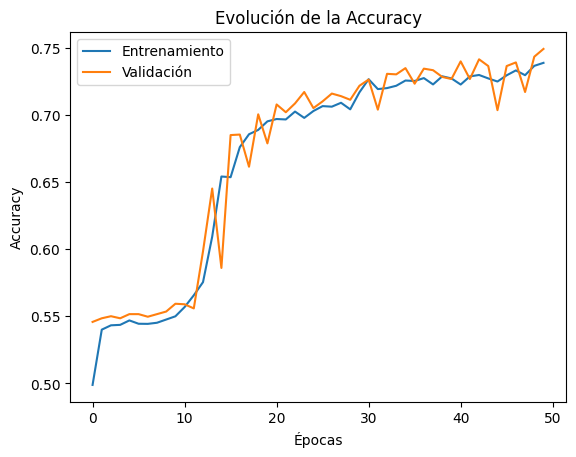

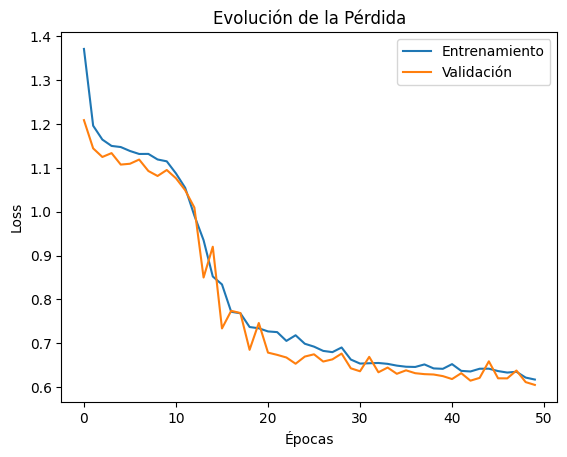

In [19]:
import matplotlib.pyplot as plt

# Gráfico de accuracy
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Evolución de la Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Gráfico de pérdida
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Evolución de la Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
F1-score for modelo_1: 0.7414887541296978


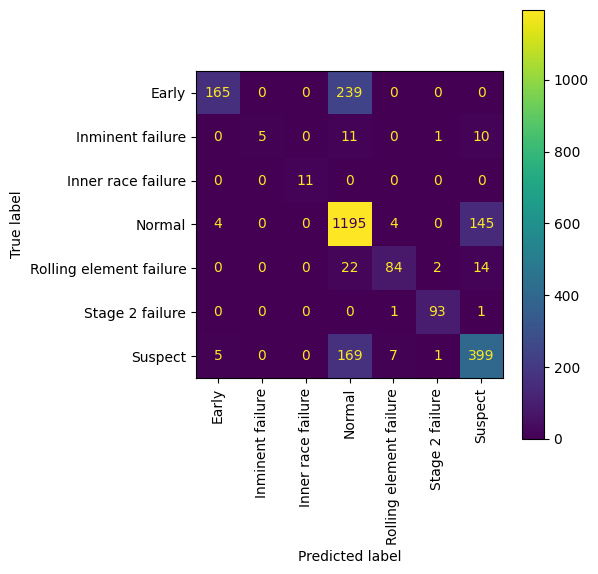

In [22]:
from sklearn.metrics import f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class ModelEvaluator:
    """
    A class to evaluate a trained model by calculating F1-score and confusion matrix.
    """
    def __init__(self, model, X, y_true):
        """
        Initializes the ModelEvaluator with the trained model, input data, and true labels.

        Args:l
            model: The trained Keras model.
            X (np.ndarray): The input data for evaluation.
            y_true (np.ndarray): The true labels (one-hot encoded).
        """
        self.model = model
        self.X = X
        self.y_true = y_true
        self.y_pred_probs = self.model.predict(self.X)
        self.y_pred_labels = np.argmax(self.y_pred_probs, axis=1)
        self.y_true_labels = np.argmax(self.y_true, axis=1)


    def calculate_f1_score(self, average='weighted'):
        """
        Calculates the F1-score.

        Args:
            average (str): The type of averaging to perform. See sklearn.metrics.f1_score for options.

        Returns:
            float: The calculated F1-score.
        """
        return f1_score(self.y_true_labels, self.y_pred_labels, average=average)

    # def plot_confusion_matrix(self, display_labels=None):
    #     """
    #     Plots the confusion matrix.

    #     Args:
    #         display_labels (list, optional): The labels to display on the confusion matrix.
    #                                          If None, integer labels will be used.
    #     """

    #     cm = confusion_matrix(self.y_true_labels, self.y_pred_labels)
    #     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    #     disp.plot()
    #     plt.show()
    def plot_confusion_matrix(self, display_labels=None):
      """
      Plots the confusion matrix with rotated X-axis labels.
      """

      cm = confusion_matrix(self.y_true_labels, self.y_pred_labels)
      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

      # Crear el gráfico y obtener el eje
      fig, ax = plt.subplots(figsize=(6, 6))
      disp.plot(ax=ax)

      # Rotar los labels en el eje X
      plt.setp(ax.get_xticklabels(), rotation=90, ha="center")

      # Ajustar el diseño y mostrar
      plt.tight_layout()
      plt.show()

# Instantiate the ModelEvaluator class
model_evaluator_4 = ModelEvaluator(modelo_4, X_test_lstm, Y_test)

# Calculate and print the F1-score
f1 = model_evaluator_4.calculate_f1_score()
print(f"F1-score for modelo_1: {f1}")

# Plot the confusion matrix
# You might want to get the actual labels from the LabelEncoder if you have it
# For now, it will use integer labels
model_evaluator_4.plot_confusion_matrix(display_labels=list(y_label_decoder.values()))